<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/ANOVA_clase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATOS ORIGINALES:
     Industria  Horas_Uso
0     Bancaria         12
1     Bancaria         10
2     Bancaria         10
3     Bancaria         12
4     Bancaria         10
5   Detallista          8
6   Detallista          8
7   Detallista          6
8   Detallista          8
9   Detallista         10
10  De seguros         10
11  De seguros          8
12  De seguros          6
13  De seguros          8
14  De seguros         10

Medias por Industria:
  Bancaria: 10.8000
  Detallista: 8.4000
  De seguros: 8.0000
Media Global: 9.0667

TABLA ANOVA DE UNA VÍA
Fuente de Variación            SC     gl           CM            F      Valor-p
--------------------------------------------------------------------------------
Entre Industrias          22.9333      2      11.4667       5.7333     0.017880
Error                     24.0000     12       2.0000
Total                     46.9333     14

INTERPRETACIÓN ANOVA (α = 0.05):
  F calculado = 5.7333
  F crítico = 3.8853
  Valor-p = 0.017880
 

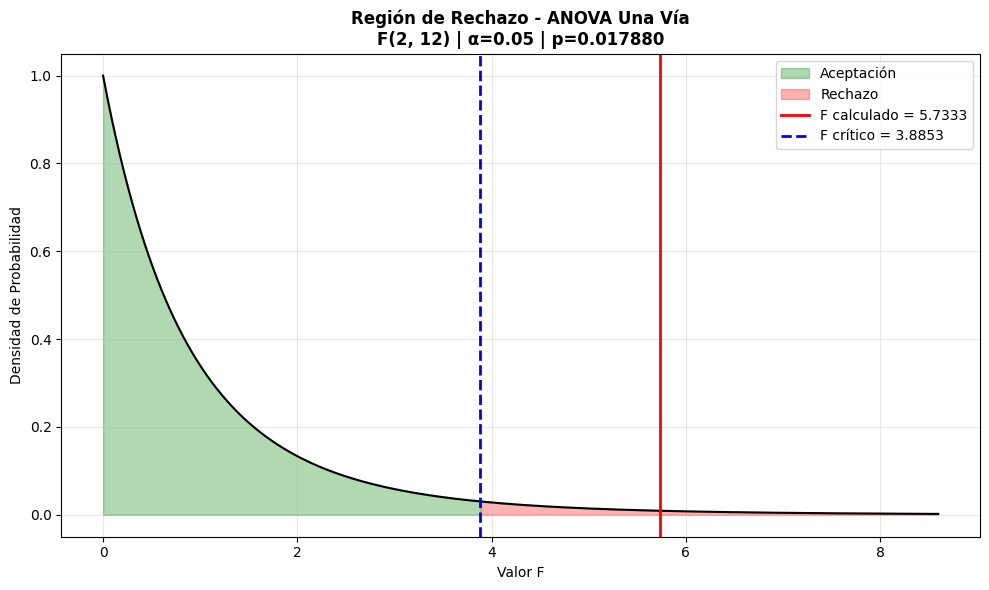

ANÁLISIS COMPLETO FINALIZADO


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================

data = {
    'Industria': ['Bancaria'] * 5 + ['Detallista'] * 5 + ['De seguros'] * 5,
    'Horas_Uso': [12, 10, 10, 12, 10, 8, 8, 6, 8, 10, 10, 8, 6, 8, 10]
}

df = pd.DataFrame(data)
industrias = df['Industria'].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

datos = [df[df['Industria'] == a]['Horas_Uso'].values for a in industrias]
n_grupos = len(industrias)
n_obs = [len(g) for g in datos]
n_total = sum(n_obs)

media_global = df['Horas_Uso'].mean()
medias_industria = df.groupby('Industria')['Horas_Uso'].mean().values

print("DATOS ORIGINALES:")
print(df)
print("\nMedias por Industria:")
for i, industria in enumerate(industrias):
    print(f"  {industria}: {medias_industria[i]:.4f}")
print(f"Media Global: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

SCT = np.sum((df['Horas_Uso'] - media_global)**2)
SCB = sum([n_obs[i]*(medias_industria[i] - media_global)**2 for i in range(n_grupos)])
SCE = SCT - SCB

gl_b = n_grupos - 1
gl_e = n_total - n_grupos
gl_t = n_total - 1

CMb = SCB / gl_b
CMe = SCE / gl_e

F = CMb / CMe
alpha = 0.05 # Nivel de significancia
p_value = 1 - stats.f.cdf(F, gl_b, gl_e)
F_crit = stats.f.ppf(1 - alpha, gl_b, gl_e)

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("TABLA ANOVA DE UNA VÍA")
print("="*80)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
print("-"*80)
print(f"{'Entre Industrias':<20} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_t:>6}")
print("="*80)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
print(f"  F calculado = {F:.4f}")
print(f"  F crítico = {F_crit:.4f}")
print(f"  Valor-p = {p_value:.6f}")

if p_value < alpha:
    print("  ✓ Hay diferencias significativas entre las medias de horas de uso de las computadoras en las industrias.")

    # ============================================================================
    # ANÁLISIS POST-HOC DE TUKEY HSD
    # ============================================================================
    print("\n============================================================================")
    print("ANÁLISIS POST-HOC: TUKEY HSD")
    print("============================================================================")
    tukey_results = pairwise_tukeyhsd(endog=df['Horas_Uso'], groups=df['Industria'], alpha=alpha)
    print(tukey_results)
    print("\nInterpretación Tukey HSD:")
    print("  'reject=True' indica una diferencia significativa entre las medias de los grupos comparados.")

else:
    print("  ✗ No hay diferencias significativas entre las medias de horas de uso de las computadoras en las industrias.")

# ============================================================================
# GRÁFICO DE REGIÓN DE RECHAZO
# ============================================================================

x = np.linspace(0, max(F, F_crit)*1.5, 1000)
y = stats.f.pdf(x, gl_b, gl_e)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=1.5)
plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
plt.title(f'Región de Rechazo - ANOVA Una Vía\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)